<a href="https://colab.research.google.com/github/Namesakenberg/BrickByBrickML/blob/main/handling_Outliers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [191]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [192]:
pd.set_option('display.max_rows',None)
pd.set_option('display.max_columns',None)
pd.set_option('display.max_colwidth',None)

In [193]:
df = pd.read_csv('/content/gurgaon_properties_cleaned_v2.csv')

In [194]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_builtup_area,builtup_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,signature global park 4,sector 36,0.82,7585.0,1081.0,Super Built up area 1081(100.43 sq.m.)Carpet area: 650 sq.ft. (60.39 sq.m.),3,2,2,2.0,NaN,New Property,1081.0,NaN,650.0,0,0,0,0,0,0,8
1,flat,smart world gems,sector 89,0.95,8600.0,1105.0,Carpet area: 1103 (102.47 sq.m.),2,2,2,4.0,NaN,New Property,NaN,NaN,1103.0,1,1,0,0,0,0,38
2,flat,pyramid elite,sector 86,0.46,79.0,58228.0,Carpet area: 58141 (5401.48 sq.m.),2,2,1,0.0,NaN,Under Construction,NaN,NaN,58141.0,0,0,0,0,0,1,15
3,flat,breez global hill view,sohna road,0.32,5470.0,585.0,Built Up area: 1000 (92.9 sq.m.)Carpet area: 585 sq.ft. (54.35 sq.m.),2,2,1,17.0,NaN,New Property,NaN,1000.0,585.0,0,0,0,0,0,1,49
4,flat,bestech park view sanskruti,sector 92,1.60,8020.0,1995.0,Super Built up area 1995(185.34 sq.m.)Built Up area: 1615 sq.ft. (150.04 sq.m.)Carpet area: 1476 sq.ft. (137.12 sq.m.),3,4,3+,10.0,North-West,Relatively New,1995.0,1615.0,1476.0,0,1,0,0,1,2,174


In [195]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3803 entries, 0 to 3802
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   property_type       3803 non-null   object 
 1   society             3802 non-null   object 
 2   sector              3803 non-null   object 
 3   price               3785 non-null   float64
 4   price_per_sqft      3785 non-null   float64
 5   area                3785 non-null   float64
 6   areaWithType        3803 non-null   object 
 7   bedRoom             3803 non-null   int64  
 8   bathroom            3803 non-null   int64  
 9   balcony             3803 non-null   object 
 10  floorNum            3784 non-null   float64
 11  facing              2698 non-null   object 
 12  agePossession       3803 non-null   object 
 13  super_builtup_area  1915 non-null   float64
 14  builtup_area        1733 non-null   float64
 15  carpet_area         1944 non-null   float64
 16  study 

In [196]:
# removing outliers of all the numerical columns one by one

# for the data following the normal distribution , the outliers are beyond mean +- 3 std devs
# and for the data not following the normal distribution make a boxplot

#Price

/tmp/ipython-input-197-444587821.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price'])


<Axes: xlabel='price', ylabel='Density'>

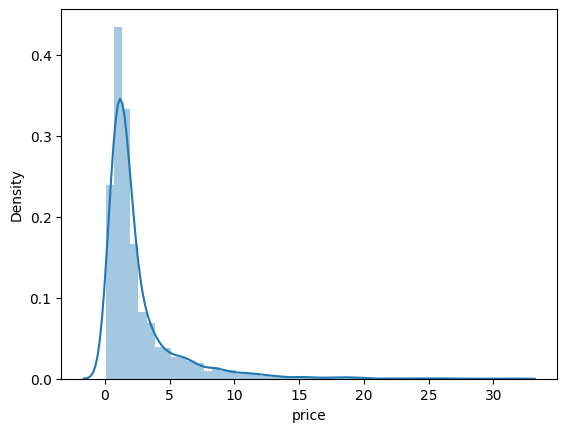

In [197]:
sns.distplot(df['price'])

<Axes: xlabel='price'>

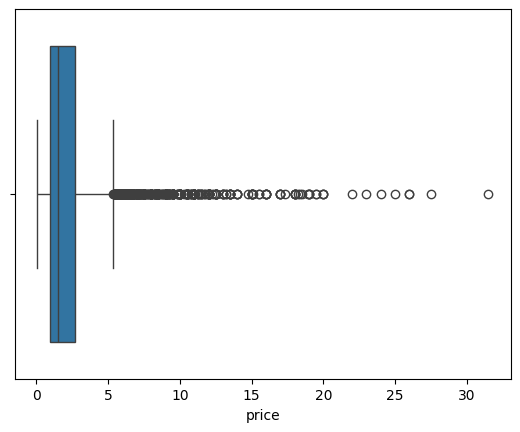

In [198]:
sns.boxplot(x = df['price'])

In [199]:
q1 = df['price'].quantile(0.25)
q3 = df['price'].quantile(0.75)
iqr = q3-q1

lower_bound = q1 - (1.5*iqr)
upper_bound = q3 + (1.5*iqr)

outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]

num_outliers = outliers.shape[0]
outliers['price'].describe()

,price
count,432.000000
mean,9.196157
std,4.061291
min,5.350000
25%,6.400000
50%,8.000000
75%,10.607500
max,31.500000


In [200]:
outliers = outliers.sort_values('price',ascending=False)

In [201]:
#from google.colab import files

#outliers.to_excel('price_outliers.xlsx',index = False)
#files.download('price_outliers.xlsx')

In [202]:
# in the price column there are genuine outliers but data errors also exist

price per sqft

/tmp/ipython-input-203-2186227091.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price_per_sqft'])


<Axes: xlabel='price_per_sqft', ylabel='Density'>

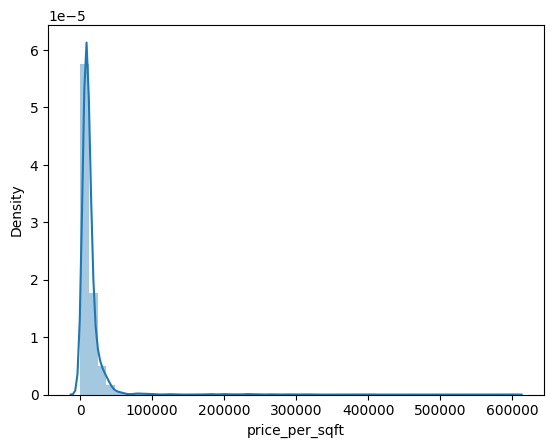

In [203]:
sns.distplot(df['price_per_sqft'])

<Axes: xlabel='price_per_sqft'>

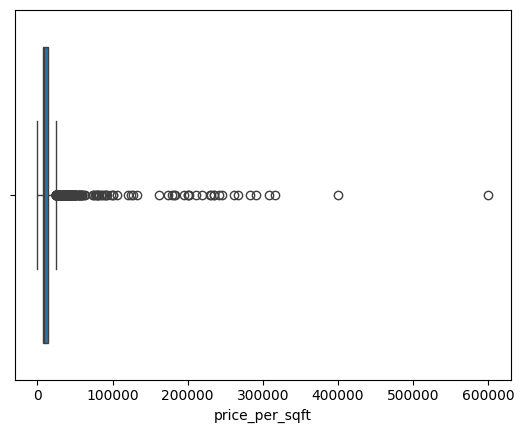

In [204]:
sns.boxplot(x = df['price_per_sqft'])

In [205]:
q1 = df['price_per_sqft'].quantile(0.25)
q3 = df['price_per_sqft'].quantile(0.75)
iqr = q3-q1

lower_bound = q1 - (1.5*iqr)
upper_bound = q3 + (1.5*iqr)

outliers_sqft= df[(df['price_per_sqft'] < lower_bound) | (df['price_per_sqft'] > upper_bound)]

num_outliers_sqft= outliers_sqft.shape[0]
outliers_sqft['price_per_sqft'].describe()

outliers_sqft= outliers.sort_values('price_per_sqft',ascending =False)

In [206]:
outliers_sqft['price_per_sqft'].describe()

,price_per_sqft
count,432.000000
mean,36598.393519
std,52016.345056
min,1560.000000
25%,19291.250000
50%,26343.500000
75%,35240.000000
max,600000.000000


In [207]:
#from google.colab import files

#outliers_sqft.to_excel('price_per_sqft_outliers.xlsx',index = False)
#files.download('price_per_sqft_outliers.xlsx')

In [208]:
def set_units(x):
    if x < 1000:
        return x * 9
    else:
        return x

outliers_sqft['area'] = outliers_sqft['area'].apply(set_units)

In [209]:

outliers_sqft['price_per_sqft'] = round((outliers_sqft['price']*10000000)/outliers_sqft['area'])

In [210]:
outliers_sqft['price_per_sqft'].describe()

,price_per_sqft
count,432.000000
mean,26804.553241
std,11436.858838
min,1560.000000
25%,19286.000000
50%,25586.000000
75%,33951.000000
max,82540.000000


In [211]:
df.update(outliers_sqft)

<Axes: xlabel='price_per_sqft', ylabel='Density'>

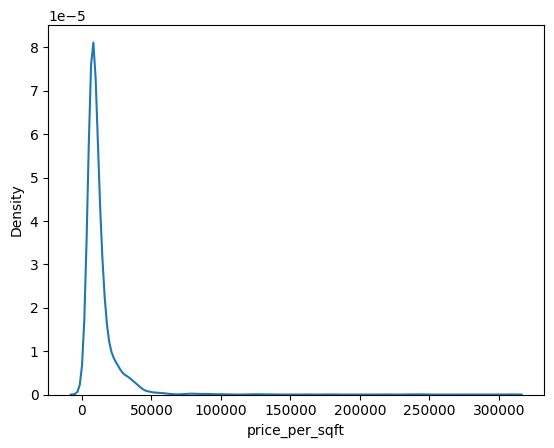

In [212]:
sns.kdeplot(df['price_per_sqft'])

<Axes: xlabel='price_per_sqft'>

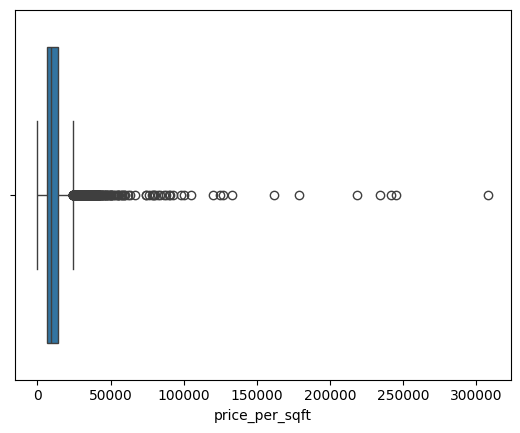

In [213]:
sns.boxplot(x = df['price_per_sqft'])

In [214]:
df[df['price_per_sqft']>50000].shape

(45, 23)

In [215]:
df=df[df['price_per_sqft']<=50000]    # remove the values having proce per sqft greater than 50k

<Axes: xlabel='price_per_sqft'>

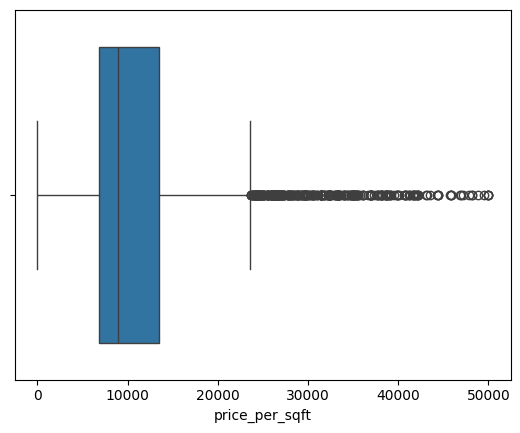

In [216]:
sns.boxplot(x=df['price_per_sqft'])

# Area

/tmp/ipython-input-217-91062565.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['area'])


<Axes: xlabel='area', ylabel='Density'>

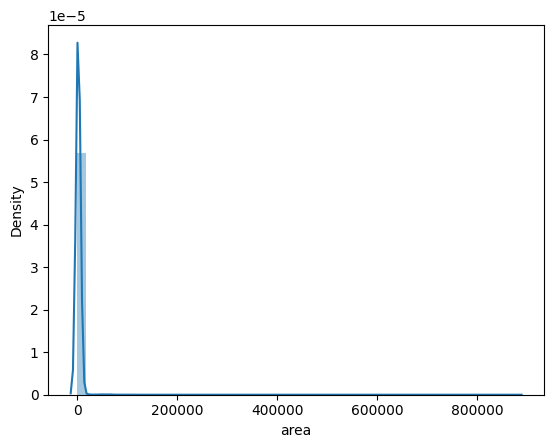

In [217]:
sns.distplot(df['area'])

<Axes: xlabel='area'>

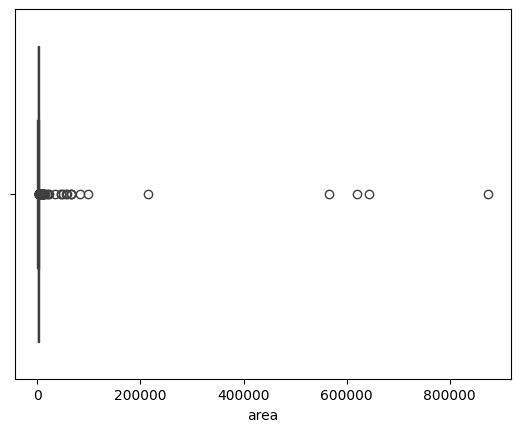

In [218]:
sns.boxplot(x = df['area'])

In [219]:
q1 = df['area'].quantile(0.25)
q3 = df['area'].quantile(0.75)
iqr = q3-q1

lower_bound = q1 - (1.5*iqr)
upper_bound = q3 + (1.5*iqr)

outliers_area= df[(df['area'] < lower_bound) | (df['area'] > upper_bound)]

num_outliers_sqft= outliers_area.shape[0]
outliers_area['area'].describe()

outliers_area= outliers.sort_values('area',ascending =False)

In [220]:
df[df['area']>100000].shape[0]

5

In [221]:
df=df[df['area']<100000]

/tmp/ipython-input-222-91062565.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['area'])


<Axes: xlabel='area', ylabel='Density'>

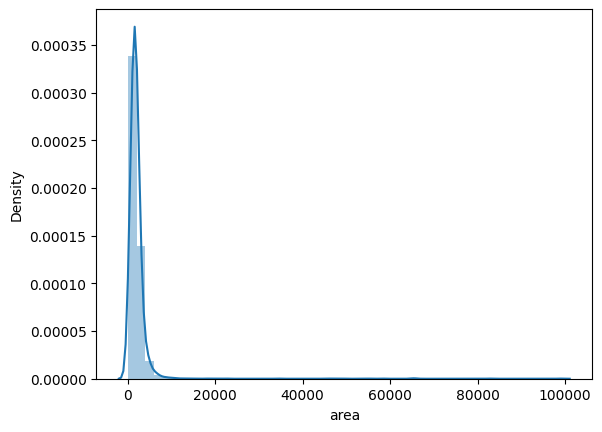

In [222]:
sns.distplot(df['area'])

<Axes: xlabel='area'>

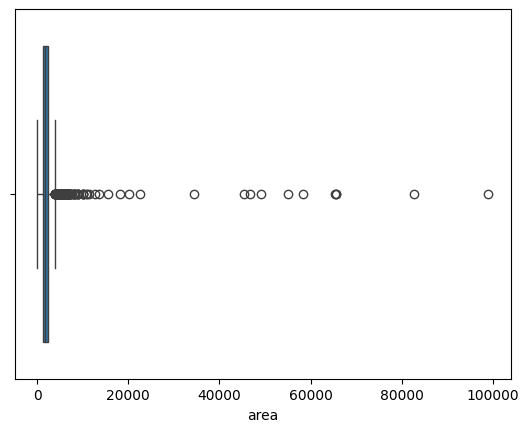

In [223]:
sns.boxplot(x=df['area'])

In [224]:
df[df['area']>10000].sort_values('area',ascending=False)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_builtup_area,builtup_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
818,house,independent,sector 26,18.40,1859.0,98978.0,Plot area 502(419.74 sq.m.)Carpet area: 11000 sq.yards (9197.4 sq.m.),6,8,3+,4.0,South,Relatively New,NaN,NaN,11000.00,0,1,1,1,0,2,60
48,house,ganpati heights apartment,sector 13,1.25,151.0,82781.0,Plot area 115(7692.86 sq.m.),10,6,2,3.0,South-East,Old Property,NaN,82781.0,NaN,0,0,0,0,1,1,7
1123,flat,rof ananda,sector 95,0.38,58.0,65517.0,Carpet area: 64412 (5984.07 sq.m.),3,2,1,12.0,North,Relatively New,NaN,NaN,64412.00,0,0,0,0,0,0,51
1796,flat,rof ananda,sector 95,0.38,58.0,65517.0,Carpet area: 64529 (5994.94 sq.m.),2,2,2,10.0,East,New Property,NaN,NaN,64529.00,1,0,0,0,0,0,15
300,house,dlf city plot phase 4,sector 28,13.00,1992.0,65261.0,Carpet area: 7250 (6061.92 sq.m.),10,10,3+,1.0,NaN,undefined,NaN,NaN,7250.00,0,0,0,0,0,1,0
2,flat,pyramid elite,sector 86,0.46,79.0,58228.0,Carpet area: 58141 (5401.48 sq.m.),2,2,1,0.0,NaN,Under Construction,NaN,NaN,58141.00,0,0,0,0,0,1,15
2356,flat,rof ananda,sector 95,0.33,60.0,55000.0,Carpet area: 54917 (5101.96 sq.m.),2,2,1,13.0,South-West,Relatively New,NaN,NaN,54917.00,0,0,0,0,0,0,37
115,flat,signature the serenas,sohna road,0.28,57.0,49123.0,Carpet area: 48811 (4534.69 sq.m.),1,1,2,1.0,North-West,Relatively New,NaN,NaN,48811.00,1,0,0,0,0,0,37
2666,house,independent,sector 25,7.30,1560.0,46795.0,Plot area 215(179.77 sq.m.)Built Up area: 5800 sq.yards (4849.54 sq.m.)Carpet area: 5200 sq.yards (4347.86 sq.m.),9,9,2,3.0,North-West,Relatively New,NaN,5800.0,5200.00,0,1,1,0,0,2,109
3649,flat,ramsons kshitij,sector 95,0.24,53.0,45283.0,Carpet area: 45966 (4270.38 sq.m.),2,2,1,10.0,North-West,Relatively New,NaN,NaN,45966.00,0,0,0,0,1,0,33


In [225]:
df.drop(index=[818, 1796, 1123, 2, 2356, 115, 3649, 2503, 1471], inplace=True)

In [226]:
df[df['area']>10000].sort_values('area',ascending=False)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_builtup_area,builtup_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
48,house,ganpati heights apartment,sector 13,1.25,151.0,82781.0,Plot area 115(7692.86 sq.m.),10,6,2,3.0,South-East,Old Property,NaN,82781.0,NaN,0,0,0,0,1,1,7
300,house,dlf city plot phase 4,sector 28,13.00,1992.0,65261.0,Carpet area: 7250 (6061.92 sq.m.),10,10,3+,1.0,NaN,undefined,NaN,NaN,7250.00,0,0,0,0,0,1,0
2666,house,independent,sector 25,7.30,1560.0,46795.0,Plot area 215(179.77 sq.m.)Built Up area: 5800 sq.yards (4849.54 sq.m.)Carpet area: 5200 sq.yards (4347.86 sq.m.),9,9,2,3.0,North-West,Relatively New,NaN,5800.0,5200.00,0,1,1,0,0,2,109
1358,house,independent,sector 57,6.25,2778.0,22498.0,Plot area 3100(2591.99 sq.m.)Built Up area: 2660 sq.yards (2224.1 sq.m.)Carpet area: 2500 sq.yards (2090.32 sq.m.),9,9,3+,3.0,North-East,New Property,NaN,2660.0,2500.00,0,1,0,0,0,2,61
3195,house,independent,sector 43,5.50,2716.0,20250.0,Plot area 215(179.77 sq.m.)Built Up area: 2850 sq.yards (2382.96 sq.m.)Carpet area: 2250 sq.yards (1881.29 sq.m.),8,7,3+,3.0,East,Moderately Old,NaN,2850.0,2250.00,1,1,0,1,1,2,123
2131,flat,godrej air,sector 85,2.50,1379.0,18129.0,Carpet area: 18122 (1683.59 sq.m.),4,5,3+,16.0,North-East,Under Construction,NaN,NaN,18122.00,1,0,0,1,1,2,44
3088,house,unitech aspen greens,sector 50,6.95,4490.0,15479.0,Plot area 240(200.67 sq.m.)Built Up area: 2160 sq.yards (1806.04 sq.m.)Carpet area: 1720 sq.yards (1438.14 sq.m.),3,3,1,2.0,North-East,Moderately Old,NaN,2160.0,1720.00,0,1,0,0,0,1,160
3444,flat,godrej icon,sector 88a,1.75,1384.0,12645.0,Carpet area: 1175.11,3,3,3+,6.0,NaN,New Property,NaN,NaN,1175.11,0,0,0,0,0,1,55
2834,house,independent,sector 43,27.50,24366.0,11286.0,Plot area 1254(1048.5 sq.m.),6,7,3+,3.0,North-East,Relatively New,NaN,11286.0,NaN,1,1,0,1,1,2,42
2342,flat,m3m golfestate,sector 65,13.20,12000.0,11000.0,Carpet area: 11000 (1021.93 sq.m.),4,4,3,13.0,North,Moderately Old,NaN,NaN,11000.00,0,1,0,0,0,1,60


In [227]:

df.loc[48,'area'] = 115*9
df.loc[300,'area'] = 7250
df.loc[2666,'area'] = 5800
df.loc[1358,'area'] = 2660
df.loc[3195,'area'] = 2850
df.loc[2131,'area'] = 1812
df.loc[3088,'area'] = 2160
df.loc[3444,'area'] = 1175

/tmp/ipython-input-228-91062565.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['area'])


<Axes: xlabel='area', ylabel='Density'>

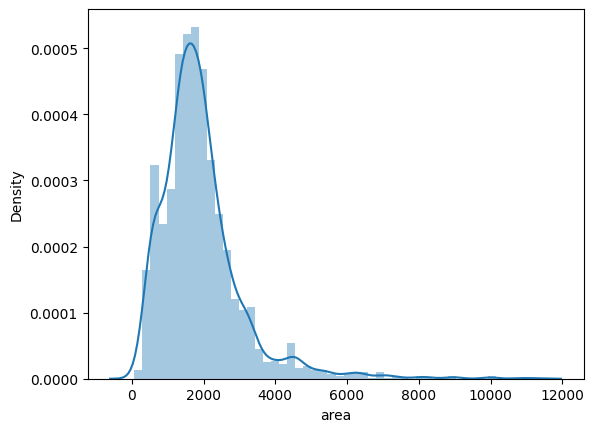

In [228]:
sns.distplot(df['area'])

<Axes: xlabel='area'>

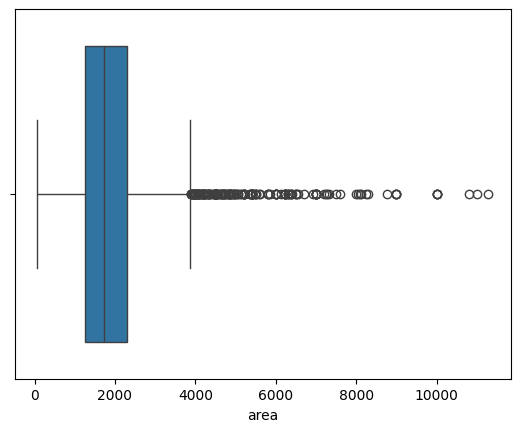

In [229]:
sns.boxplot(x=df['area'])

In [230]:
df['area'].describe()

,area
count,3726.000000
mean,1914.521739
std,1171.167992
min,72.000000
25%,1246.250000
50%,1735.000000
75%,2298.000000
max,11286.000000


#Bedroom

/tmp/ipython-input-231-1691983684.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bedRoom'])


<Axes: xlabel='bedRoom', ylabel='Density'>

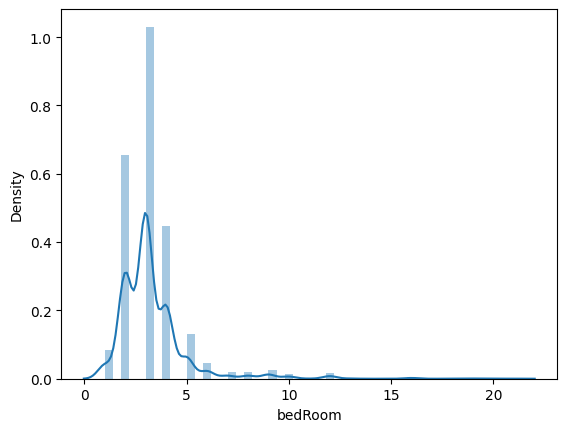

In [231]:
sns.distplot(df['bedRoom'])

<Axes: xlabel='bedRoom'>

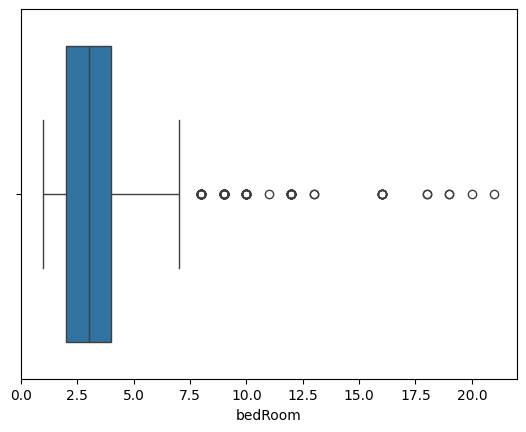

In [232]:
sns.boxplot(x=df['bedRoom'])

In [233]:
df['bedRoom'].describe()

,bedRoom
count,3726.000000
mean,3.293881
std,1.775085
min,1.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,21.000000


In [234]:
df[df['bedRoom']>10].sort_values('bedRoom',ascending=False)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_builtup_area,builtup_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
3618,house,independent,sector 54,5.00,43066.0,1161.0,Plot area 129(107.86 sq.m.),21,21,3+,5.0,North,Relatively New,NaN,1161.0,NaN,0,1,0,0,0,0,49
2611,house,independent,sector 43,4.50,39062.0,1152.0,Plot area 128(107.02 sq.m.),20,20,3+,4.0,East,Relatively New,NaN,1152.0,NaN,0,1,0,0,0,0,22
78,house,independent,sector 17a,3.87,5160.0,7500.0,Plot area 1623(150.78 sq.m.)Built Up area: 7500 sq.ft. (696.77 sq.m.),19,17,3+,5.0,North-West,Relatively New,NaN,7500.0,NaN,1,0,1,0,0,0,68
1493,house,independent,sector 17a,3.93,24214.0,1623.0,Plot area 1623(150.78 sq.m.)Built Up area: 1622 sq.ft. (150.69 sq.m.),19,17,3,4.0,North-West,Relatively New,NaN,1622.0,NaN,1,1,1,1,0,0,74
1381,house,private house,sector 55,7.05,46906.0,1503.0,Plot area 167(139.63 sq.m.),18,18,3+,4.0,North-East,Relatively New,NaN,1503.0,NaN,0,0,0,0,1,0,57
19,house,independent,sector 54,5.50,38194.0,1440.0,Plot area 160(133.78 sq.m.),18,18,3+,4.0,South-West,Relatively New,NaN,1440.0,NaN,0,1,0,0,0,0,70
372,house,independent,sector 11,4.50,25000.0,1800.0,Plot area 200(167.23 sq.m.),16,16,3+,4.0,South,Relatively New,NaN,1800.0,NaN,0,0,0,0,0,2,20
2096,house,luxury dlf city floors,sector 26,20.00,48888.0,4091.0,Plot area 500(418.06 sq.m.),16,16,3+,4.0,NaN,New Property,NaN,4091.0,NaN,0,1,0,0,0,2,31
3698,house,independent,sector 55,9.19,34037.0,2700.0,Plot area 300(250.84 sq.m.),16,18,2,4.0,West,New Property,NaN,2700.0,NaN,0,1,0,1,0,2,49
3457,house,independent,sector 56,12.39,45889.0,2700.0,Plot area 300(250.84 sq.m.),16,18,3+,4.0,North-East,New Property,NaN,2700.0,NaN,0,1,0,1,0,2,49


In [235]:
df = df[df['bedRoom']<=10]

In [236]:
df.shape

(3686, 23)

/tmp/ipython-input-237-1691983684.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bedRoom'])


<Axes: xlabel='bedRoom', ylabel='Density'>

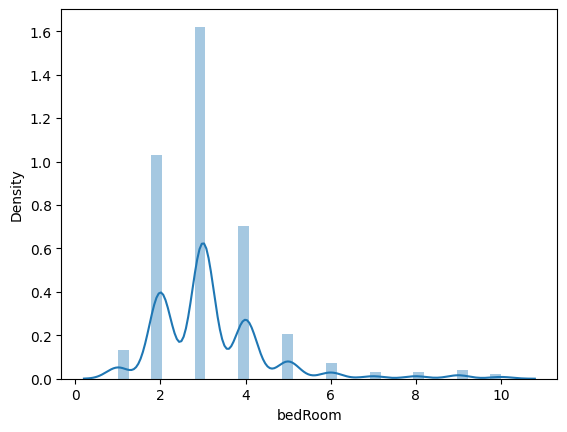

In [237]:
sns.distplot(df['bedRoom'])

<Axes: xlabel='bedRoom'>

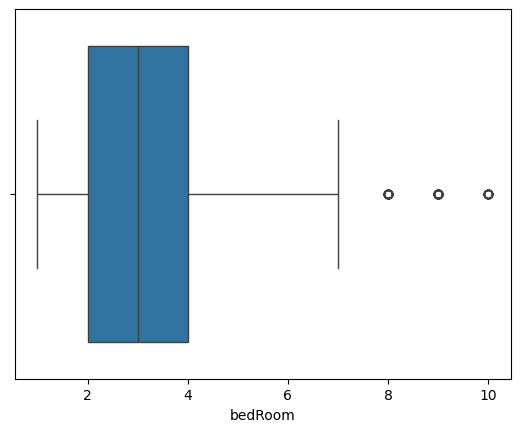

In [238]:
sns.boxplot(x=df['bedRoom'])

In [239]:
df['bedRoom'].describe()

,bedRoom
count,3686.00000
mean,3.17987
std,1.37567
min,1.00000
25%,2.00000
50%,3.00000
75%,4.00000
max,10.00000


## bathrooms

/tmp/ipython-input-240-2904465235.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bathroom'])


<Axes: xlabel='bathroom', ylabel='Density'>

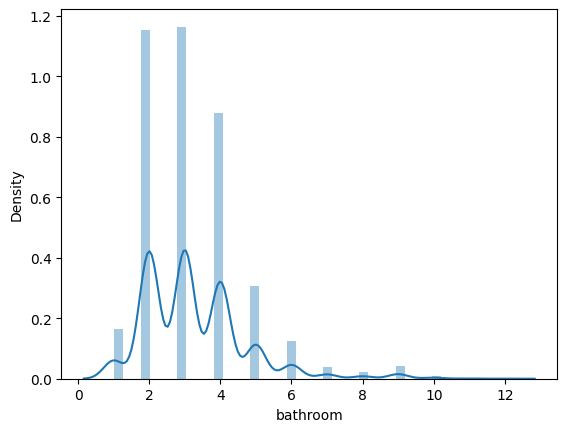

In [240]:
sns.distplot(df['bathroom'])

<Axes: xlabel='bathroom'>

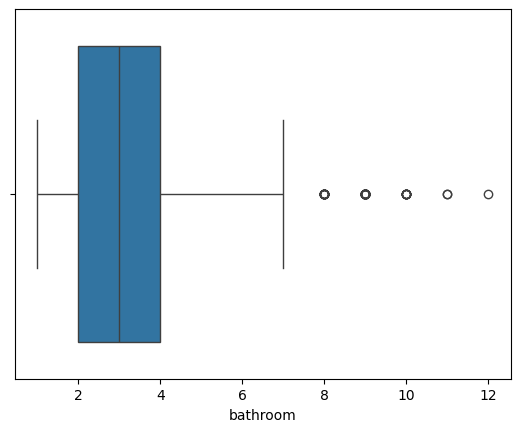

In [241]:
sns.boxplot(x=df['bathroom'])

In [242]:
df[df['bathroom']>10].sort_values('bathroom',ascending=False)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_builtup_area,builtup_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
3267,house,adani brahma samsara,sector 60,18.02,28200.0,6390.0,Built Up area: 6390 (593.65 sq.m.),9,12,3+,3.0,North-East,Relatively New,NaN,6390.0,NaN,0,1,0,0,0,2,146
2771,house,independent,sector 39,7.00,10000.0,7000.0,Plot area 350(32.52 sq.m.)Built Up area: 7000 sq.ft. (650.32 sq.m.),10,11,3+,4.0,South-East,Relatively New,NaN,7000.0,NaN,0,0,0,1,0,2,38
2816,house,independent,sector 24,11.00,28902.0,3806.0,Plot area 3806.45(353.63 sq.m.)Built Up area: 5000 sq.ft. (464.52 sq.m.),8,11,3+,3.0,East,Old Property,NaN,5000.0,NaN,1,1,0,1,1,2,39


## super built up area

/tmp/ipython-input-243-523907216.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['super_builtup_area'])


<Axes: xlabel='super_builtup_area', ylabel='Density'>

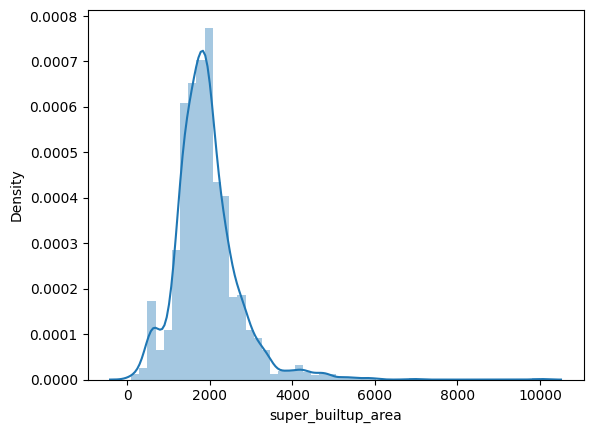

In [243]:
sns.distplot(df['super_builtup_area'])

<Axes: xlabel='super_builtup_area'>

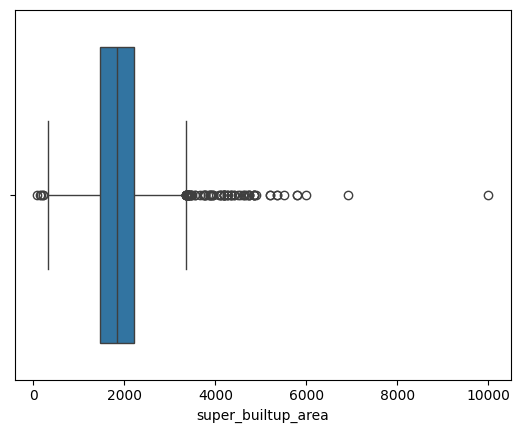

In [244]:
sns.boxplot(x=df['super_builtup_area'])

In [245]:
df['super_builtup_area'].describe()

,super_builtup_area
count,1915.000000
mean,1921.658251
std,767.160169
min,89.000000
25%,1457.000000
50%,1828.000000
75%,2215.000000
max,10000.000000


In [246]:
df[df['super_builtup_area']>6000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_builtup_area,builtup_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1323,flat,bestech park view grand spa,sector 81,4.7,6786.0,6926.0,Super Built up area 6926(643.45 sq.m.),4,4,3+,19.0,North,Relatively New,6926.0,NaN,NaN,0,1,0,0,0,2,140
3265,flat,krrish provence estate,gwal pahari,7.5,7500.0,10000.0,Super Built up area 10000(929.03 sq.m.),5,6,3+,23.0,North-East,Relatively New,10000.0,NaN,NaN,0,1,0,1,1,0,49


## built up area

/tmp/ipython-input-247-2996519323.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['builtup_area'])


<Axes: xlabel='builtup_area', ylabel='Density'>

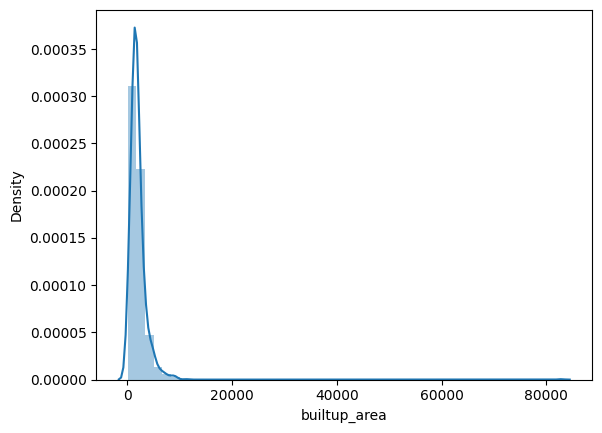

In [247]:
sns.distplot(df['builtup_area'])

<Axes: xlabel='builtup_area'>

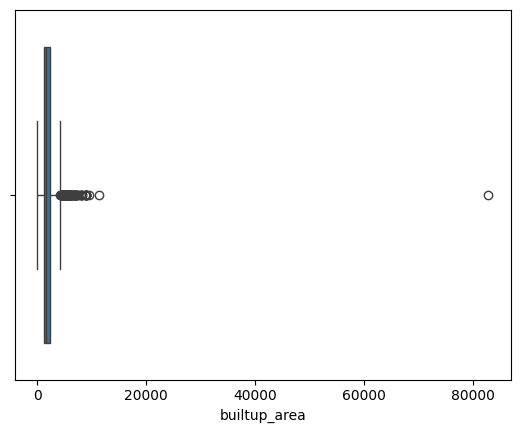

In [248]:
sns.boxplot(x=df['builtup_area'])

In [249]:
df['builtup_area'].describe()

,builtup_area
count,1631.000000
mean,2032.963280
std,2437.494395
min,50.000000
25%,1185.500000
50%,1700.000000
75%,2400.000000
max,82781.000000


In [250]:
df[df['builtup_area'] > 10000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_builtup_area,builtup_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
48,house,ganpati heights apartment,sector 13,1.25,151.0,1035.0,Plot area 115(7692.86 sq.m.),10,6,2,3.0,South-East,Old Property,NaN,82781.0,NaN,0,0,0,0,1,1,7
2834,house,independent,sector 43,27.50,24366.0,11286.0,Plot area 1254(1048.5 sq.m.),6,7,3+,3.0,North-East,Relatively New,NaN,11286.0,NaN,1,1,0,1,1,2,42


In [251]:
df = df.drop(48)

## carpet area


/tmp/ipython-input-252-3905767603.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['carpet_area'])


<Axes: xlabel='carpet_area', ylabel='Density'>

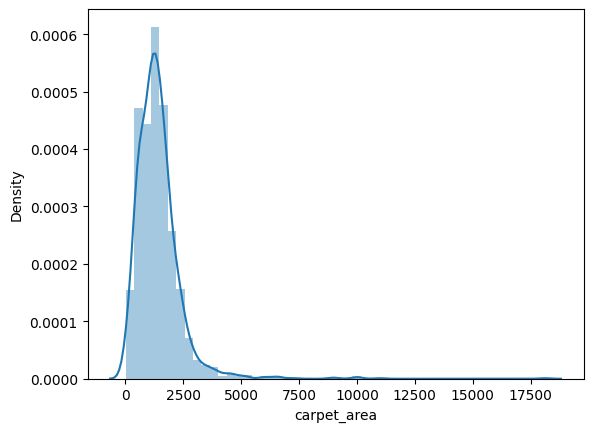

In [252]:
sns.distplot(df['carpet_area'])

<Axes: xlabel='carpet_area'>

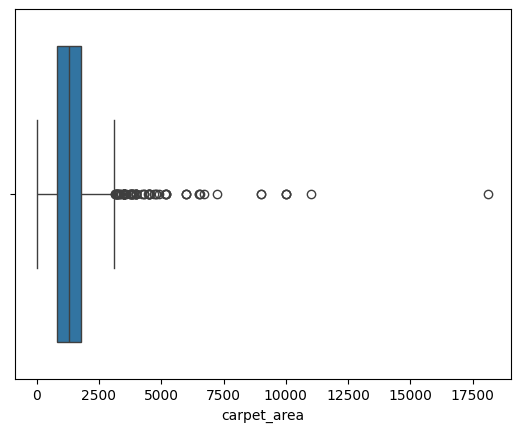

In [253]:
sns.boxplot(x=df['carpet_area'])

In [254]:
df[df['carpet_area'] > 10000]


,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_builtup_area,builtup_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2131,flat,godrej air,sector 85,2.5,1379.0,1812.0,Carpet area: 18122 (1683.59 sq.m.),4,5,3+,16.0,North-East,Under Construction,NaN,NaN,18122.0,1,0,0,1,1,2,44
2342,flat,m3m golfestate,sector 65,13.2,12000.0,11000.0,Carpet area: 11000 (1021.93 sq.m.),4,4,3,13.0,North,Moderately Old,NaN,NaN,11000.0,0,1,0,0,0,1,60


In [255]:
df.loc[2131,'carpet_area'] = 1812

/tmp/ipython-input-256-3385064764.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['luxury_score'])


<Axes: xlabel='luxury_score', ylabel='Density'>

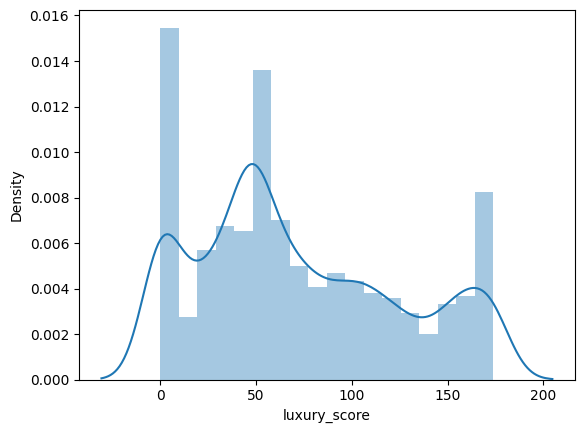

In [256]:
sns.distplot(df['luxury_score'])

<Axes: xlabel='luxury_score'>

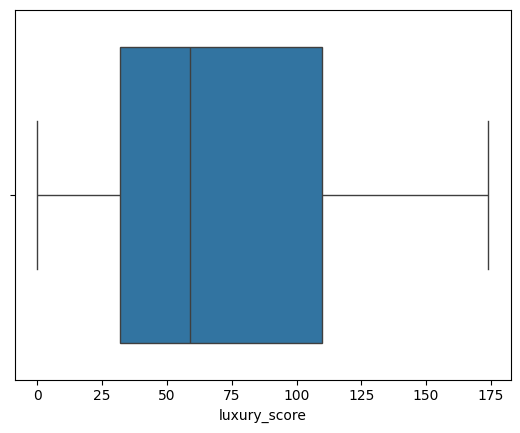

In [257]:
sns.boxplot(x=df['luxury_score'])

In [258]:
df.shape

(3685, 23)

In [259]:
df['price_per_sqft'] = round((df['price']*10000000)/df['area'])

/tmp/ipython-input-260-2186227091.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price_per_sqft'])


<Axes: xlabel='price_per_sqft', ylabel='Density'>

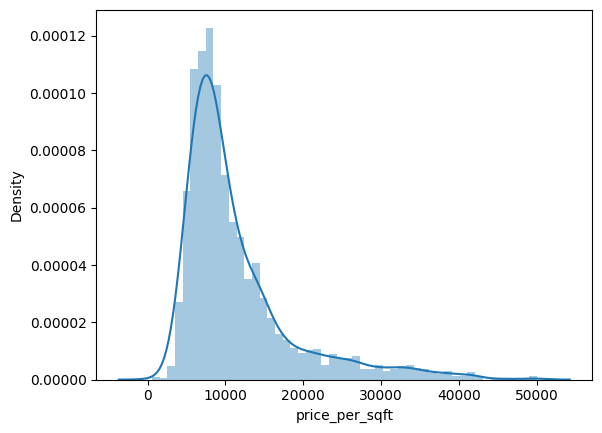

In [260]:
sns.distplot(df['price_per_sqft'])

<Axes: xlabel='price_per_sqft'>

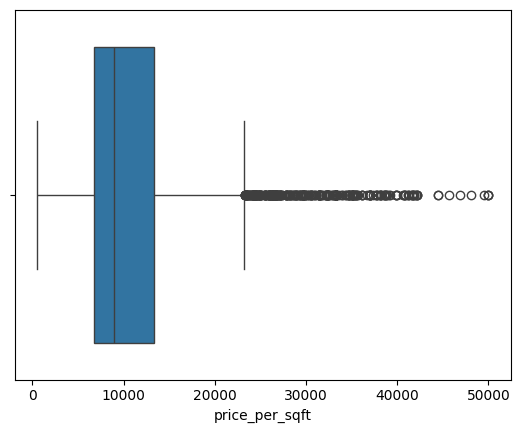

In [261]:
sns.boxplot(x=df['price_per_sqft'])

In [262]:
df[df['price_per_sqft'] > 42000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_builtup_area,builtup_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
90,house,independent,sector 105,0.50,50000.0,100.0,Built Up area: 100 (9.29 sq.m.),2,2,0,1.0,NaN,undefined,NaN,100.0,NaN,0,0,0,0,0,0,0
711,house,independent,sector 26,20.00,44444.0,4500.0,Plot area 500(418.06 sq.m.),5,7,3+,3.0,West,Relatively New,NaN,4500.0,NaN,0,1,0,1,0,0,97
901,house,independent,sector 28,12.00,42194.0,2844.0,Plot area 316(264.22 sq.m.),4,5,3+,4.0,East,Relatively New,NaN,2844.0,NaN,0,1,1,1,0,2,60
1090,house,independent,sector 105,9.90,49500.0,2000.0,Built Up area: 2000 (185.81 sq.m.)Carpet area: 1800 sq.ft. (167.23 sq.m.),2,2,2,3.0,North,undefined,NaN,2000.0,1800.000000,0,0,0,0,0,1,0
1509,house,independent,sector 55,5.00,44444.0,1125.0,Plot area 125(104.52 sq.m.)Built Up area: 115 sq.yards (96.15 sq.m.)Carpet area: 100 sq.yards (83.61 sq.m.),9,9,3+,5.0,East,New Property,NaN,115.0,100.000000,0,0,0,0,1,2,44
1526,house,dlf city plots,sector 26,19.00,42054.0,4518.0,Plot area 502(419.74 sq.m.),6,6,3,2.0,East,Relatively New,NaN,4518.0,NaN,1,1,0,0,0,2,121
2040,house,independent,sector 43,9.50,42222.0,2250.0,Plot area 302(252.51 sq.m.)Built Up area: 300 sq.yards (250.84 sq.m.)Carpet area: 250 sq.yards (209.03 sq.m.),5,5,3+,2.0,North-East,Relatively New,NaN,300.0,250.000000,0,1,0,1,0,2,88
2056,flat,breez global hill view,sohna road,2.60,46931.0,554.0,Carpet area: 554.16 (51.48 sq.m.),2,2,2,6.0,NaN,New Property,NaN,NaN,554.125572,0,0,0,0,0,0,42
2130,house,independent,sector 26,19.00,42222.0,4500.0,Plot area 500(418.06 sq.m.),6,8,3+,3.0,East,Moderately Old,NaN,4500.0,NaN,1,1,1,1,0,2,103
2297,flat,lig flat,sector 40,1.50,50000.0,300.0,Built Up area: 300 (27.87 sq.m.),1,1,0,0.0,NaN,undefined,NaN,300.0,NaN,0,0,0,0,0,1,0


## area and bedroom

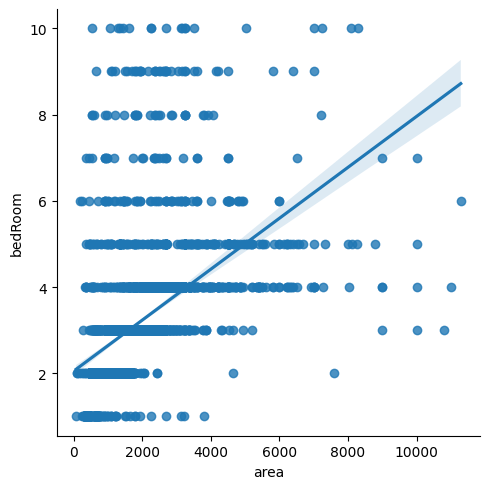

In [276]:
sns.lmplot(data=df , x='area',y='bedRoom')      # relation between area and bedroom

In [267]:
x = df[df['price_per_sqft'] <= 20000]

(x['area']/x['bedRoom']).quantile(0.02) # get the ratio of area:beadroom and 2nd percentile , i.e very low values

np.float64(199.4)

In [264]:
# 200 sqft is the 2nd percentile value , which is the threshold to identify the properies having data error like lesser area but more rooms

In [272]:
df[df['area']/df['bedRoom']<=200].sample(5)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_builtup_area,builtup_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
733,house,independent,sector 2,1.15,19360.0,594.0,Plot area 66(55.18 sq.m.),3,3,2,2.0,South-East,Old Property,NaN,594.0,NaN,0,0,0,0,0,2,32
3162,house,independent,sector 24,1.45,26852.0,540.0,Plot area 60(50.17 sq.m.),3,3,1,NaN,NaN,Old Property,NaN,540.0,NaN,0,0,0,0,0,0,9
2889,house,madan puri,sector 7,0.75,12500.0,600.0,Plot area 600(55.74 sq.m.),3,5,3,3.0,South-East,Moderately Old,NaN,600.0,NaN,0,0,0,0,0,1,0
215,house,bhawani enclave,sector 12,0.42,8235.0,510.0,Plot area 565(52.49 sq.m.)Carpet area: 510 sq.ft. (47.38 sq.m.),3,3,0,2.0,East,New Property,NaN,NaN,510.0,0,0,0,1,0,1,0
3101,house,independent,sector 9,1.25,8735.0,1431.0,Plot area 159(132.94 sq.m.),10,6,3+,3.0,NaN,Old Property,NaN,1431.0,NaN,0,0,0,0,0,1,0


In [274]:
df[df['area'] / df['bedRoom'] <=200].shape[0]

# there exist 103 properties where the area given is small but the number of bedrooms in the house is high , thus it is a data error

103

In [278]:
df['area_per_room']= df['area'] / df['bedRoom']

In [282]:
(df[df['area_per_room']<250])['bedRoom'].value_counts()

,count
bedRoom,
2,49
3,37
5,24
4,23
6,19
9,15
8,12
7,10
10,8


In [283]:
# remove those datapoints in which the raito of the area per room is lesser than 100
df = df[df['area_per_room']>100]

In [285]:
outliers_area_per_room = df[(df['area_per_room']<250) & (df['bedRoom']>3)]

In [286]:
outliers_area_per_room['bedRoom'] = round(outliers_area_per_room['bedRoom']/outliers_area_per_room['floorNum'])

/tmp/ipython-input-286-1559125316.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers_area_per_room['bedRoom'] = round(outliers_area_per_room['bedRoom']/outliers_area_per_room['floorNum'])


In [287]:
df.update(outliers_area_per_room)

In [291]:
df[(df['area_per_room'] <250 )&(df['bedRoom'] > 4)].shape

(12, 24)

In [292]:
# still there are 12 values having non justifiable area and bedrooms , thus remove such values aswell

df = df[~((df['area_per_room']<250)&(df['bedRoom']>4))]

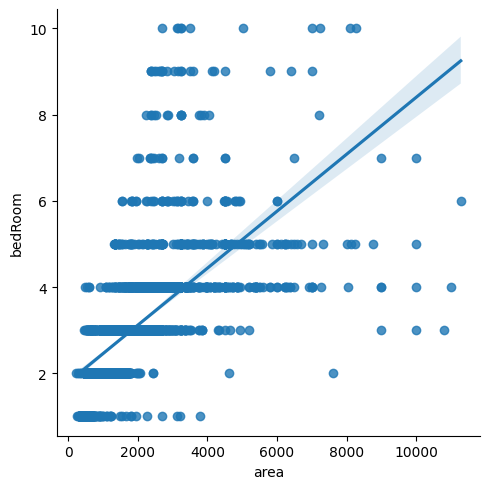

In [294]:
sns.lmplot(data = df , x='area',y='bedRoom')

In [296]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_builtup_area,builtup_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_per_room
0,flat,signature global park 4,sector 36,0.82,7586.0,1081.0,Super Built up area 1081(100.43 sq.m.)Carpet area: 650 sq.ft. (60.39 sq.m.),3,2,2,2.0,NaN,New Property,1081.0,NaN,650.0,0,0,0,0,0,0,8,360.333333
1,flat,smart world gems,sector 89,0.95,8597.0,1105.0,Carpet area: 1103 (102.47 sq.m.),2,2,2,4.0,NaN,New Property,NaN,NaN,1103.0,1,1,0,0,0,0,38,552.500000
3,flat,breez global hill view,sohna road,0.32,5470.0,585.0,Built Up area: 1000 (92.9 sq.m.)Carpet area: 585 sq.ft. (54.35 sq.m.),2,2,1,17.0,NaN,New Property,NaN,1000.0,585.0,0,0,0,0,0,1,49,292.500000
4,flat,bestech park view sanskruti,sector 92,1.60,8020.0,1995.0,Super Built up area 1995(185.34 sq.m.)Built Up area: 1615 sq.ft. (150.04 sq.m.)Carpet area: 1476 sq.ft. (137.12 sq.m.),3,4,3+,10.0,North-West,Relatively New,1995.0,1615.0,1476.0,0,1,0,0,1,2,174,665.000000
5,flat,suncity avenue,sector 102,0.48,9023.0,532.0,Super Built up area 632(58.71 sq.m.)Carpet area: 532 sq.ft. (49.42 sq.m.),2,2,1,5.0,North-East,Relatively New,632.0,NaN,532.0,0,0,1,0,0,1,159,266.000000


In [297]:
df.to_csv('gurgaon_properties_outlier_treated.csv',index=False)